#Analisando a criação do Qubit e a esfera de Bloch

In [ ]:
%%capture
!pip install qiskit[visualization]==1.2.2
!pip install qiskit_aer
!pip install qiskit_ibm_runtime
!pip install matplotlib

In [ ]:
import qiskit
from qiskit import QuantumCircuit, transpile
from qiskit import QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
import qiskit.quantum_info as qi
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler

#Exemplos dos Circuitos mais básicos

**Circuito de 1 Qubit:**

Aqui está um circuito simples para 1 qubit:

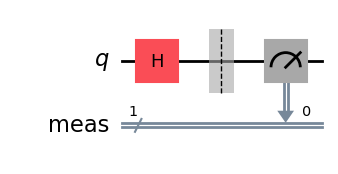

In [ ]:
qc1 = QuantumCircuit(1)
qc1.h(0)
qc1.measure_all()
qc1.draw('mpl')

In [ ]:
# Use o simulador Qiskit Aer para executar o circuito
simulator = AerSimulator()
compiled_circuit = transpile(qc1, simulator)
result = simulator.run(compiled_circuit).result()

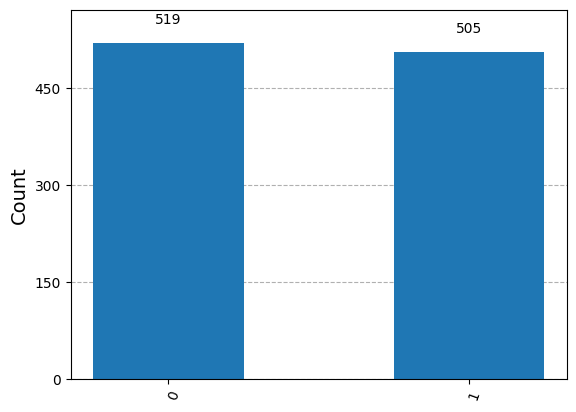

In [ ]:
# Obtenha a contagem dos resultados e visualize os resultados
counts = result.get_counts()
plot_histogram(counts)

**Circuito de 2 Qubits:**

Aqui está um circuito simples para 2 qubits:

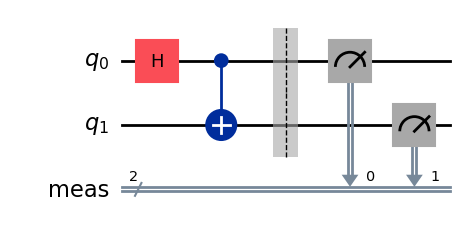

In [ ]:
qc2 = QuantumCircuit(2)
qc2.h(0)                                                           #aplica porta Hadamar
qc2.cx(0, 1)                                                       #Porta CNOT com controle no primeiro qubit e alvo no segundo qubit
qc2.measure_all()
qc2.draw('mpl')

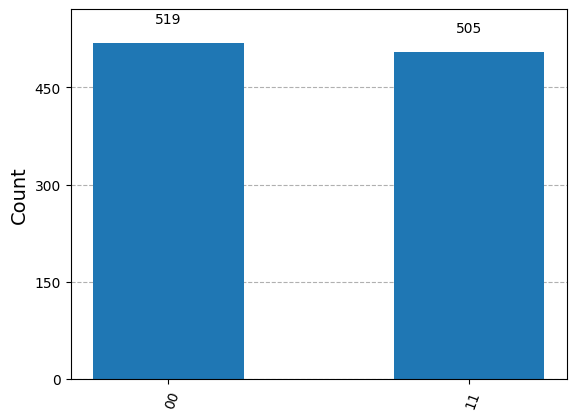

In [ ]:
# Use o simulador Qiskit Aer para executar o circuito
simulator = AerSimulator()
compiled_circuit = transpile(qc2, simulator)
result = simulator.run(compiled_circuit).result()

# Obtenha a contagem dos resultados e visualize os resultados
counts = result.get_counts()
plot_histogram(counts)

**Circuito de 3 Qubits:**

Aqui está um circuito simples para 3 qubits:

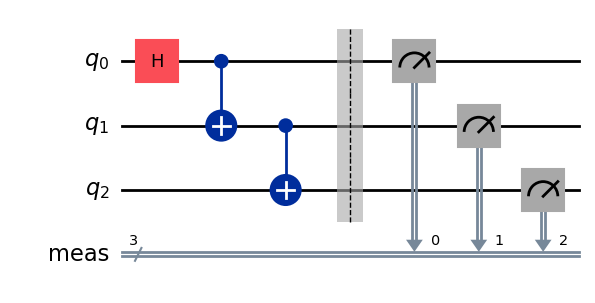

In [ ]:
qc3 = QuantumCircuit(3)
qc3.h(0)                                                                   #aplica porta Hadamard
qc3.cx(0, 1)                                                               #CNOT com controle no primeiro qubit e alvo no segundo qubit
qc3.cx(1, 2)                                                               #CNOT com controle no segundo qubit e alvo no terceiro qubit
qc3.measure_all()
qc3.draw('mpl')

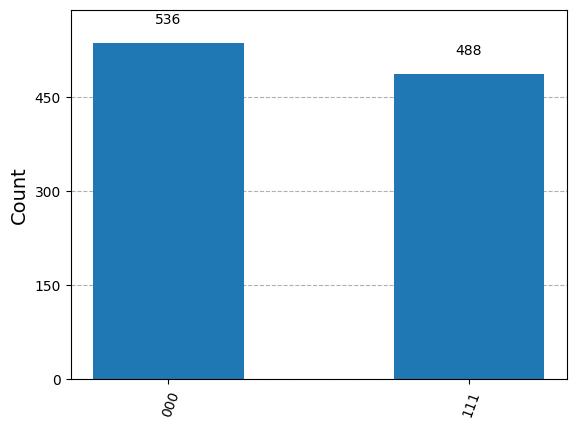

In [ ]:
# Use o simulador Qiskit Aer para executar o circuito
simulator = AerSimulator()
compiled_circuit = transpile(qc3, simulator)
result = simulator.run(compiled_circuit).result()

# Obtenha a contagem dos resultados e visualize os resultados
counts = result.get_counts()
plot_histogram(counts)

**Circuito de 4 Qubits:**

Aqui está um circuito simples para 4 qubits:

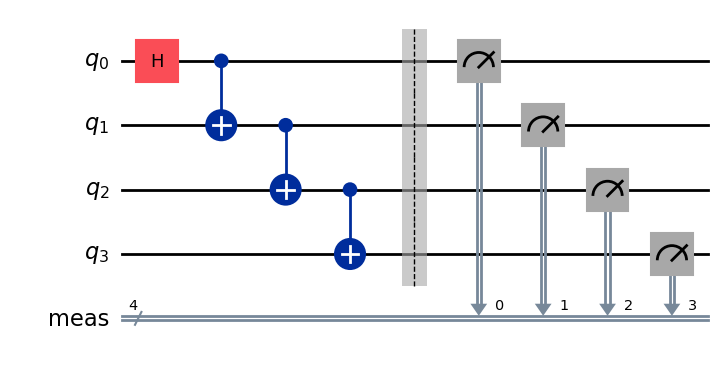

In [ ]:
qc4 = QuantumCircuit(4)
qc4.h(0)                                                            #Porta Hadamard no primeiro qubit
qc4.cx(0, 1)                                                        #CNOT com controle no primeiro qubit e alvo no segundo qubit
qc4.cx(1, 2)                                                        #CNOT com controle no segundo qubit e alvo no terceiro qubit
qc4.cx(2, 3)                                                        #CNOT com controle no terceiro qubit e alvo no quarto qubit
qc4.measure_all()
qc4.draw('mpl')

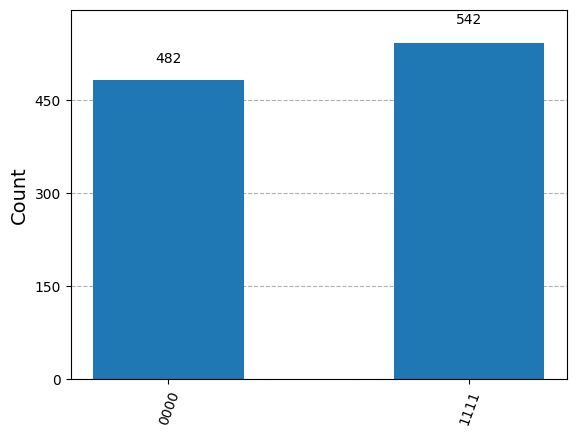

In [ ]:
# Use o simulador Qiskit Aer para executar o circuito
simulator = AerSimulator()
compiled_circuit = transpile(qc4, simulator)
result = simulator.run(compiled_circuit).result()

# Obtenha a contagem dos resultados e visualize os resultados
counts = result.get_counts()
plot_histogram(counts)

# Teremos o mesmo resultado se realizado no computador quântico?

Até o momento o que fizemos foi simulação quãntica. Por questões de estudo, testes e pesquisa, a simulação é satifastório em muitos pontos. Realizar cálculos em computador quãntico requer um pouco de tempo. A IBM, por exemplo, deisponiliza 8 minutos por mês para cada cpf realizar cálculos nos seus computadores quânticos. Isso implica entrar numa fila para rodar o programa. o que implica tempo.

**Realizando os cáclculos num computador real**

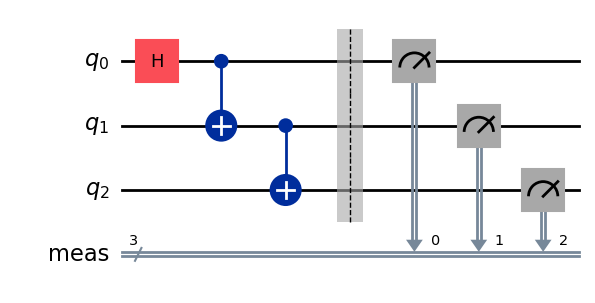

In [ ]:
# Criando o circuito de 3 qubtis e realizando as operações
circ3 = QuantumCircuit(3)
circ3.h(0)                                                                   #aplica porta Hadamard
circ3.cx(0, 1)                                                               #CNOT com controle no primeiro qubit e alvo no segundo qubit
circ3.cx(1, 2)                                                               #CNOT com controle no segundo qubit e alvo no terceiro qubit
circ3.measure_all()
circ3.draw('mpl')

In [ ]:
service = QiskitRuntimeService(channel="ibm_quantum",
                               token = '39096e7a3b61144409089599e4a7c833fb42342fe2cfec9e66a416c322927860ac402202d87a09efdedb7eaafb98a5874bbf2def57ee0b6354c27878e2baa3da')
backend = service.least_busy(operational=True, simulator=False)

In [ ]:
#Fazer a conta no computador quãntico da IBM. O cálculo fica numa fila para ser executado.
pm = generate_preset_pass_manager(backend=backend, optimization_level=2)
isa_circuit = pm.run(circ3)

Counts: {'110': 27, '111': 1856, '000': 2035, '011': 32, '001': 76, '100': 26, '010': 24, '101': 20}


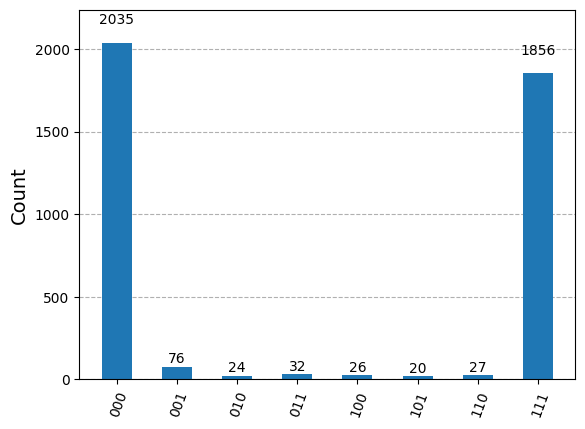

In [ ]:
#Em seguida uma amostragem é realizada e o resultado é apresentado
sampler = Sampler(backend)
job = sampler.run([(isa_circuit)])
result = job.result()
pub_result = result[0]
counts = pub_result.data.meas.get_counts()
print("Counts:", counts)
plot_histogram(counts)